<a href="https://colab.research.google.com/github/greeshmapj/AI-course-notes/blob/main/Sec18_Feature_engineering_Classification_case_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import seaborn as sns
data=sns.load_dataset("iris")

In [ ]:
target=data["species"]
target.value_counts() # class balanced (counts are same)

,count
species,
setosa,50
versicolor,50
virginica,50


In [ ]:
y=data["species"] #target
y

,species
0,setosa
1,setosa
2,setosa
3,setosa
4,setosa
...,...
145,virginica
146,virginica
147,virginica
148,virginica


In [ ]:
data["species"].value_counts() #data is balanced, very good

,count
species,
setosa,50
versicolor,50
virginica,50


# Techniques for Handling Class Imbalance in Machine Learning

Class imbalance occurs when one class has significantly more instances than another. This can negatively impact model performance, leading to biased predictions. Below are various techniques to balance the dataset.#

In [ ]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

# Load the dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)

# Add target column
df['Target'] = data.target  # 0 = FALSE, 1 = TRUE

df.sample(3)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Target
96,12.180,17.84,77.79,451.1,0.10450,0.07057,0.02490,0.02941,0.1900,0.06635,...,20.92,82.14,495.2,0.1140,0.09358,0.0498,0.05882,0.2227,0.07376,1
155,12.250,17.94,78.27,460.3,0.08654,0.06679,0.03885,0.02331,0.1970,0.06228,...,25.22,86.60,564.2,0.1217,0.17880,0.1943,0.08211,0.3113,0.08132,1
175,8.671,14.45,54.42,227.2,0.09138,0.04276,0.00000,0.00000,0.1722,0.06724,...,17.04,58.36,259.2,0.1162,0.07057,0.0000,0.00000,0.2592,0.07848,1


In [ ]:
df.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'Target'],
      dtype='object')

In [ ]:
df["Target"].value_counts() #imbalaced

,count
Target,
1,357
0,212


<Axes: xlabel='Target', ylabel='count'>

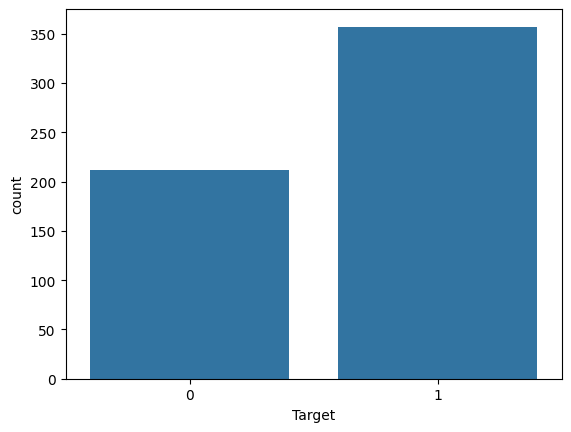

In [ ]:
sns.countplot(x=df["Target"])

In [ ]:
# Calculate Class Imbalance Ratio
maj_cls = df['Target'].value_counts().max()
min_cls = df['Target'].value_counts().min()
ratio = maj_cls / min_cls

print(f"Class Imbalance Ratio: {ratio:.2f}")


Class Imbalance Ratio: 1.68


🛠 Techniques for Different Class Imbalance Ratios  

### CIR Range & Handling Techniques  

**1.0 - 1.5 (Slight Imbalance)**  
- No major adjustments needed  
- Stratified Sampling in train-test split  

**1.5 - 3.0 (Moderate Imbalance)**  
- SMOTE (Synthetic Minority Over-sampling Technique)  

**3.0 - 10.0 (High Imbalance)**  
- SMOTE or ADASYN  

**>10.0 (Extreme Imbalance)**  
- Hybrid Approach: Over-sampling + Under-sampling  
- Anomaly Detection Methods (One-Class SVM, Isolation Forest)  


## **Introduction to SMOTE**

SMOTE (Synthetic Minority Over-sampling Technique) is a powerful oversampling method used to handle imbalanced datasets in machine learning. Instead of simply duplicating minority class samples, SMOTE generates synthetic samples by interpolating between existing minority class instances.

## **Why Use SMOTE?**

Balances the dataset, improving model performance on minority classes.

Enhances generalization by creating new, meaningful synthetic samples.

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter


In [ ]:


# Check class distribution
print("Before SMOTE:", Counter(df['Target']))

# Splitting features and target
X = df.drop(columns=['Target'])
y = df['Target']

# Apply SMOTE
smote = SMOTE(sampling_strategy='auto')

#xscaled,y
X, y = smote.fit_resample(X, y)

# Check new class distribution
print("After SMOTE:", Counter(y))

Before SMOTE: Counter({1: 357, 0: 212})
After SMOTE: Counter({0: 357, 1: 357})


<Axes: xlabel='Target', ylabel='count'>

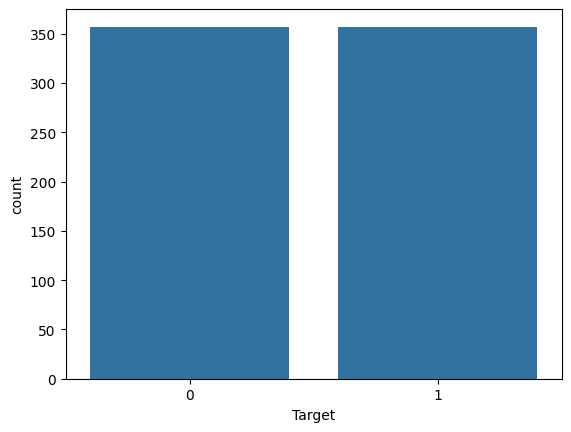

In [ ]:
import seaborn as sns
sns.countplot(x=y)

# **ADASYN (Adaptive Synthetic Sampling)** is an oversampling technique similar to SMOTE, but with a key difference:

ADASYN focuses more on harder-to-learn minority samples, generating more synthetic data in regions where the class imbalance is more severe.

In [ ]:
# Apply ADASYN
from imblearn.over_sampling import ADASYN
adasyn = ADASYN(random_state=42)
X_resampled, y_resampled = adasyn.fit_resample(X, y)

print("Original class distribution:\n", y.value_counts())
print("Resampled class distribution:\n", y_resampled.value_counts())

Original class distribution:
 Target
0    357
1    357
Name: count, dtype: int64
Resampled class distribution:
 Target
0    357
1    357
Name: count, dtype: int64


<Axes: xlabel='Target', ylabel='count'>

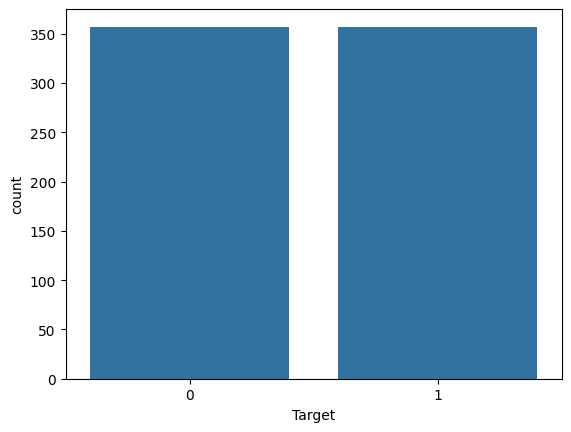

In [ ]:
import seaborn as sns
sns.countplot(x=y_resampled)

In [ ]:
from imblearn.combine import SMOTETomek
# Apply Hybrid Approach (SMOTE + Tomek Links)
smote_tomek = SMOTETomek(random_state=42)
X_resampled, y_resampled = smote_tomek.fit_resample(X, y)

print("Original class distribution:\n", y.value_counts())
print("Resampled class distribution:\n", y_resampled.value_counts())

Original class distribution:
 Target
0    357
1    357
Name: count, dtype: int64
Resampled class distribution:
 Target
0    348
1    348
Name: count, dtype: int64


<Axes: xlabel='Target', ylabel='count'>

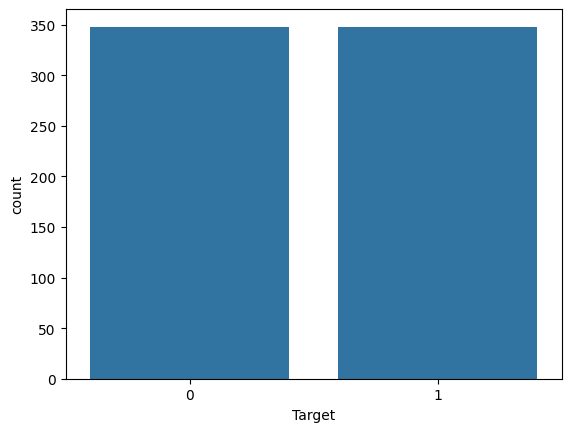

In [ ]:
import seaborn as sns
sns.countplot(x=y_resampled)

### 📊 Comparison of SMOTE, ADASYN, and Hybrid Approach  

| **Technique**          | **How It Works** | **Best for CIR Range** | **Pros** | **Cons** |  
|-----------------------|-----------------|----------------|------------------|----------------|  
| **SMOTE** (Synthetic Minority Over-sampling Technique) | Generates synthetic samples by interpolating between minority class neighbors. | **1.5 - 10** | Prevents overfitting, maintains original class distribution. | Does not consider class difficulty; may generate redundant data. |  
| **ADASYN** (Adaptive Synthetic Sampling) | Generates synthetic samples adaptively, focusing more on harder-to-learn samples. | **3 - 10** | Adaptive to class distribution, improves decision boundary. | Can introduce noise if too many difficult samples are synthesized. |  
| **Hybrid (SMOTE + Tomek/ENN)** | Combines over-sampling (e.g., SMOTE) and under-sampling (e.g., Tomek Links or ENN) to balance the dataset. | **>10** (Extreme Imbalance) | Reduces overfitting, removes noise and redundant data. | Risk of losing useful data during under-sampling. |  

### 🔥 **Key Takeaways:**  
✅ **Use SMOTE** for a moderate imbalance when a simple oversampling technique is sufficient.  
✅ **Use ADASYN** if the dataset has complex decision boundaries and difficult-to-learn samples.  
✅ **Use Hybrid (SMOTE + Under-sampling)** when dealing with extreme class imbalance (>10 CIR) to avoid excessive synthetic data.  


*pandas*
numpy
matplotlib
seaborn
sklearn
imblearn


---



#  **🏷️ Method 2: Feature Selection Using Random Forest**

## 📖 Description:  
Random Forest is an ensemble learning method that provides built-in feature importance based on how much a feature contributes to reducing impurity (Gini or MSE).  

## 🔍 Steps to Perform Feature Selection:  
1️⃣ Train a Random Forest model on the dataset.  
2️⃣ Extract feature importance scores from the trained model.  
3️⃣ Rank features by importance.  
4️⃣ Select the top K most important features based on a threshold.  

## ✅ Pros:  
✔️ Handles non-linearity and complex feature interactions.  
✔️ Works well with high-dimensional data.  
✔️ Fast & scalable compared to wrapper methods.  
✔️ No need for additional feature selection techniques.  

## ❌ Cons:  
❌ Doesn’t remove redundant features (some features may be correlated).  
❌ Sensitive to noise if the dataset is not cleaned properly.  

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split

# Load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names) #features
y = data.target #target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest Model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Get feature importance
feature_importance = pd.Series(model.feature_importances_, index=X.columns)

# Print sorted feature importance
print("🔹 **Feature Importance (High to Low):**")
print(feature_importance.sort_values(ascending=False))  #desc


🔹 **Feature Importance (High to Low):**
mean concave points        0.173221
worst concave points       0.125482
worst radius               0.121729
worst perimeter            0.120081
worst area                 0.090969
mean concavity             0.046347
mean perimeter             0.034064
mean area                  0.033870
mean radius                0.029950
area error                 0.027284
mean compactness           0.024123
worst texture              0.024009
worst concavity            0.023130
radius error               0.017074
worst symmetry             0.015167
worst smoothness           0.012103
mean texture               0.009476
concavity error            0.007664
worst fractal dimension    0.007223
compactness error          0.006950
worst compactness          0.006650
fractal dimension error    0.006334
perimeter error            0.006106
mean fractal dimension     0.006027
symmetry error             0.005279
texture error              0.005274
mean smoothness         

In [ ]:
# Select features with importance > 0.01 (threshold)
selected_features = feature_importance[feature_importance > 0.01].index
X_selected = X[selected_features]

# Print selected features
print("🔹 Selected Features (Importance > 0.01):")
print(selected_features)

🔹 Selected Features (Importance > 0.01):
Index(['mean radius', 'mean perimeter', 'mean area', 'mean compactness',
       'mean concavity', 'mean concave points', 'radius error', 'area error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst concavity', 'worst concave points',
       'worst symmetry'],
      dtype='object')


In [ ]:
len(selected_features)

16

In [ ]:
X_selected

,mean radius,mean perimeter,mean area,mean compactness,mean concavity,mean concave points,radius error,area error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst concavity,worst concave points,worst symmetry
0,17.99,122.80,1001.0,0.27760,0.30010,0.14710,1.0950,153.40,25.380,17.33,184.60,2019.0,0.16220,0.7119,0.2654,0.4601
1,20.57,132.90,1326.0,0.07864,0.08690,0.07017,0.5435,74.08,24.990,23.41,158.80,1956.0,0.12380,0.2416,0.1860,0.2750
2,19.69,130.00,1203.0,0.15990,0.19740,0.12790,0.7456,94.03,23.570,25.53,152.50,1709.0,0.14440,0.4504,0.2430,0.3613
3,11.42,77.58,386.1,0.28390,0.24140,0.10520,0.4956,27.23,14.910,26.50,98.87,567.7,0.20980,0.6869,0.2575,0.6638
4,20.29,135.10,1297.0,0.13280,0.19800,0.10430,0.7572,94.44,22.540,16.67,152.20,1575.0,0.13740,0.4000,0.1625,0.2364
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,142.00,1479.0,0.11590,0.24390,0.13890,1.1760,158.70,25.450,26.40,166.10,2027.0,0.14100,0.4107,0.2216,0.2060
565,20.13,131.20,1261.0,0.10340,0.14400,0.09791,0.7655,99.04,23.690,38.25,155.00,1731.0,0.11660,0.3215,0.1628,0.2572
566,16.60,108.30,858.1,0.10230,0.09251,0.05302,0.4564,48.55,18.980,34.12,126.70,1124.0,0.11390,0.3403,0.1418,0.2218
567,20.60,140.10,1265.0,0.27700,0.35140,0.15200,0.7260,86.22,25.740,39.42,184.60,1821.0,0.16500,0.9387,0.2650,0.4087


In [ ]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

# **project 1**

In [ ]:
import seaborn as sns
import pandas as pd

df = sns.load_dataset("titanic")
df = df[['survived','pclass','sex','age','fare','embarked']]
df.dropna(inplace=True)

X = df.drop('survived', axis=1)
y = df['survived']
X

,pclass,sex,age,fare,embarked
0,3,male,22.0,7.2500,S
1,1,female,38.0,71.2833,C
2,3,female,26.0,7.9250,S
3,1,female,35.0,53.1000,S
4,3,male,35.0,8.0500,S
...,...,...,...,...,...
885,3,female,39.0,29.1250,Q
886,2,male,27.0,13.0000,S
887,1,female,19.0,30.0000,S
889,1,male,26.0,30.0000,C


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_cols = ['age','fare']
cat_cols = ['sex','embarked','pclass']

preprocess = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first'), cat_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [ ]:
y_train.value_counts()

,count
survived,
0,339
1,230


In [ ]:
y.value_counts()

maj_cls = y.value_counts().max()
min_cls = y.value_counts().min()
ratio = maj_cls / min_cls

print(f"Class Imbalance Ratio: {ratio:.2f}")

Class Imbalance Ratio: 1.47


In [ ]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE


In [ ]:
from sklearn.feature_selection import SelectKBest


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC


In [ ]:
pipe_lr = Pipeline([
    ('prep', preprocess),
    ('smote', SMOTE(random_state=42)),
    ('fs', SelectKBest(k=15)),
    ('model', LogisticRegression())
])

pipe_dt = Pipeline([
    ('prep', preprocess),
    ('smote', SMOTE(random_state=42)),
    ('model', DecisionTreeClassifier())
])

pipe_rf = Pipeline([
    ('prep', preprocess),
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier())
])

pipe_nb = Pipeline([
    ('prep', preprocess),
    ('smote', SMOTE(random_state=42)),
    ('model', GaussianNB())
])

pipe_svc = Pipeline([
    ('prep', preprocess),
    ('smote', SMOTE(random_state=42)),
    ('model', SVC(probability=True))
])


In [ ]:
from sklearn.metrics import accuracy_score

pipe_lr.fit(X_train, y_train)
pipe_dt.fit(X_train, y_train)
pipe_rf.fit(X_train, y_train)
pipe_nb.fit(X_train, y_train)
pipe_svc.fit(X_train, y_train)

acc_lr  = accuracy_score(y_train, pipe_lr.predict(X_train))
acc_dt  = accuracy_score(y_train, pipe_dt.predict(X_train))
acc_rf  = accuracy_score(y_train, pipe_rf.predict(X_train))
acc_nb  = accuracy_score(y_train, pipe_nb.predict(X_train))
acc_svc = accuracy_score(y_train, pipe_svc.predict(X_train))

acc_table = pd.DataFrame({
    "Model": ["Logistic","Decision Tree","Random Forest","Naive Bayes","SVC"],
    "Accuracy": [acc_lr, acc_dt, acc_rf, acc_nb, acc_svc]
})

acc_table.sort_values("Accuracy", ascending=False)


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:783: UserWarning: k=15 is greater than n_features=7. All the features will be returned.
  warnings.warn(


,Model,Accuracy
1,Decision Tree,0.987698
2,Random Forest,0.987698
4,SVC,0.820738
0,Logistic,0.811951
3,Naive Bayes,0.773286


In [ ]:
pipelines = {
    'Logistic Regression': pipe_lr,
    'Decision Tree': pipe_dt,
    'Random Forest': pipe_rf,
    'Naive Bayes': pipe_nb,
    'SVM': pipe_svc
}
#as dictionary

In [ ]:
from sklearn.metrics import accuracy_score
import pandas as pd

results = []

for name, pipe in pipelines.items():
    # Train
    pipe.fit(X_train, y_train)

    # Predictions
    y_train_pred = pipe.predict(X_train)
    y_test_pred = pipe.predict(X_test)

    # Metrics
    results.append({
        'Model': name,
        'Train Accuracy': accuracy_score(y_train, y_train_pred),
        'Test Accuracy': accuracy_score(y_test, y_test_pred) })

results_df = pd.DataFrame(results)
results_df


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:783: UserWarning: k=15 is greater than n_features=7. All the features will be returned.
  warnings.warn(


,Model,Train Accuracy,Test Accuracy
0,Logistic Regression,0.811951,0.790210
1,Decision Tree,0.987698,0.734266
2,Random Forest,0.987698,0.762238
3,Naive Bayes,0.773286,0.748252
4,SVM,0.820738,0.790210


In [ ]:
import joblib

joblib.dump(pipe_rf, "best_model.pkl")


['best_model.pkl']

In [ ]:
best_model = joblib.load("/content/best_model.pkl")

best_model


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'fare']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['sex', 'embarked',
                                                   'pclass'])])),
                ('smote', SMOTE(random_state=42)),
                ('model', RandomForestClassifier())])

In [ ]:
unseen_data = pd.DataFrame({
    'pclass': [1, 3, 2],
    'sex': ['female', 'male', 'female'],
    'age': [29, 45, 8],
    'fare': [100.0, 7.25, 20.5],
    'embarked': ['C', 'S', 'Q']
})

unseen_data


,pclass,sex,age,fare,embarked
0,1,female,29,100.00,C
1,3,male,45,7.25,S
2,2,female,8,20.50,Q


In [ ]:
unseen_predictions = best_model.predict(unseen_data)

print("Predictions:", unseen_predictions)


Predictions: [1 0 1]
